# Genetic Algorithm-Enhanced Diabetes E-Diagnosis

**Pipeline:** Pima Indians Diabetes Dataset → Pre-processing *(Chang et al., 2022)* → GA Feature Selection *(Kangra & Singh, 2024)* → Classification (J48 DT, RF, NB) → MLflow Tracking → Results

## 1. INSTALL LIBRARIES

In [1]:
!pip install pygad mlflow kagglehub --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.6/8

## 2. IMPORT LIBRARIES

In [2]:
import numpy as np
import pandas as pd
import warnings
import os
import math
import mlflow
import mlflow.sklearn
import pygad
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import kagglehub

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.base import clone
from IPython.display import display

warnings.filterwarnings('ignore')
np.random.seed(42)

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 3. LOAD DATASET

In [3]:
# Download Pima Indians Diabetes dataset from Kaggle
path = kagglehub.dataset_download('uciml/pima-indians-diabetes-database')
print('Dataset Path:', path)
print(os.listdir(path))

csv_path = os.path.join(path, 'diabetes.csv')
df = pd.read_csv(csv_path)

print('Dataset Shape:', df.shape)
df.head()

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Dataset Path: /kaggle/input/pima-indians-diabetes-database
['diabetes.csv']
Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 4. PRE-PROCESSING  *(Chang et al., 2022)*

**4.1 HANDLE INVALID ZEROS**

Biologically invalid zero values in `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI` are replaced with column median.

In [4]:
ZERO_INVALID_COLS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Zero Counts Before Imputation:')
print(df[ZERO_INVALID_COLS].eq(0).sum())

for col in ZERO_INVALID_COLS:
    median_val = df[col].replace(0, np.nan).median()
    df[col] = df[col].replace(0, median_val)

print('\nZero Counts After Imputation:')
print(df[ZERO_INVALID_COLS].eq(0).sum())

Zero Counts Before Imputation:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Zero Counts After Imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


**4.2 STANDARDIZATION**

`StandardScaler` applied to `DiabetesPedigreeFunction`, `Age`, and `Insulin` to normalise high-variance features.

In [5]:
SCALE_COLS = ['DiabetesPedigreeFunction', 'Age', 'Insulin']

scaler = StandardScaler()
df[SCALE_COLS] = scaler.fit_transform(df[SCALE_COLS])

print('Standardization Complete')
print(df[SCALE_COLS].describe().loc[['mean', 'std']].round(4))

Standardization Complete
      DiabetesPedigreeFunction     Age  Insulin
mean                    0.0000  0.0000   0.0000
std                     1.0007  1.0007   1.0007


## 5. TRAIN / TEST SPLIT

70 % Training (538 samples) / 30 % Testing (230 samples) — matches (Chang et al., 2022) exactly.

In [6]:
FEATURE_NAMES = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

X = df[FEATURE_NAMES].values
y = df['Outcome'].values

TRAIN_SIZE = 538
X_train, X_test = X[:TRAIN_SIZE], X[TRAIN_SIZE:]
y_train, y_test = y[:TRAIN_SIZE], y[TRAIN_SIZE:]

print('Training Samples:', X_train.shape[0])
print('Testing  Samples:', X_test.shape[0])

Training Samples: 538
Testing  Samples: 230


**PCA Visualization**

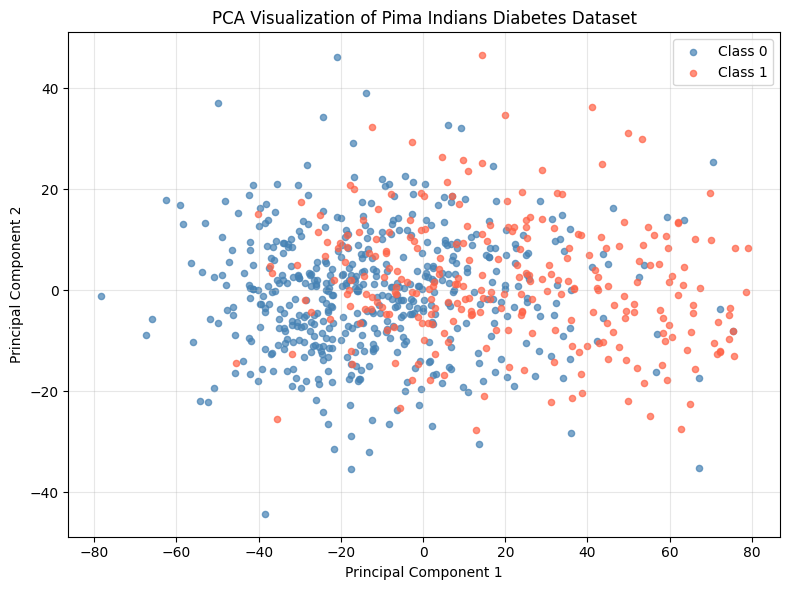

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({'PCA1': X_pca[:, 0], 'PCA2': X_pca[:, 1], 'Outcome': y})

plt.figure(figsize=(8, 6))
for label, colour in zip([0, 1], ['steelblue', 'tomato']):
    subset = pca_df[pca_df['Outcome'] == label]
    plt.scatter(subset['PCA1'], subset['PCA2'],
                label=f'Class {label}', alpha=0.7, color=colour, s=20)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Visualization of Pima Indians Diabetes Dataset')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. GENETIC ALGORITHM FEATURE SELECTION  *(Kangra & Singh, 2024)*

| Parameter | Value |
|---|---|
| Encoding | Binary (8-bit chromosome) |
| Fitness | Maximise RF accuracy on test set |
| Population | 100 |
| Generations | 50 |
| Crossover probability | 0.6 |
| Mutation probability | 0.3 (uniform random) |
| Selection | Tournament (K=3) |

**6.1 GA PARAMETERS**

In [8]:
GA_POP_SIZE    = 100
GA_GENERATIONS = 50
GA_CROSSOVER_P = 0.6
GA_MUTATION_P  = 0.3
NUM_FEATURES   = X_train.shape[1]   # 8

# RF used only inside GA fitness (internal, not final model)
_ga_rf = RandomForestClassifier(n_estimators=100, random_state=42)

**6.2 FITNESS FUNCTION**

In [9]:
def fitness_function(ga_instance, solution, solution_idx):
    """Binary chromosome: gene > 0.5 means feature selected. Fitness = RF test accuracy."""
    selected = np.where(np.array(solution) > 0.5)[0]
    if len(selected) == 0:
        return 0.0
    _ga_rf.fit(X_train[:, selected], y_train)
    preds = _ga_rf.predict(X_test[:, selected])
    return accuracy_score(y_test, preds)


print('Starting Genetic Algorithm...')
print('Population Size :', GA_POP_SIZE)
print('Generations     :', GA_GENERATIONS)

Starting Genetic Algorithm...
Population Size : 100
Generations     : 50


**6.3 RUN GENETIC ALGORITHM**

In [10]:
ga_instance = pygad.GA(
    num_generations       = GA_GENERATIONS,
    num_parents_mating    = int(GA_POP_SIZE * GA_CROSSOVER_P),
    fitness_func          = fitness_function,
    sol_per_pop           = GA_POP_SIZE,
    num_genes             = NUM_FEATURES,
    gene_type             = float,
    init_range_low        = 0,
    init_range_high       = 1,
    gene_space            = [0, 1],
    parent_selection_type = 'tournament',
    K_tournament          = 3,
    crossover_type        = 'single_point',
    crossover_probability = GA_CROSSOVER_P,
    mutation_type         = 'random',
    mutation_probability  = GA_MUTATION_P,
    keep_elitism          = 1,
    random_seed           = 42,
    suppress_warnings     = True
)

ga_instance.run()
print('GA completed.')

GA completed.


## 7. BEST SELECTED FEATURES

In [11]:
best_solution, best_fitness, _ = ga_instance.best_solution()

selected_indices  = np.where(np.array(best_solution) > 0.5)[0]
selected_features = [FEATURE_NAMES[i] for i in selected_indices]

print('GA Completed Successfully')
print('Best Accuracy (RF, test set):', round(best_fitness, 4))
print('Selected Features:', selected_features)
print(f'Number selected: {len(selected_features)} / {NUM_FEATURES}')

GA Completed Successfully
Best Accuracy (RF, test set): 0.8087
Selected Features: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Number selected: 7 / 8


**Chart 1: GA Fitness Evolution**

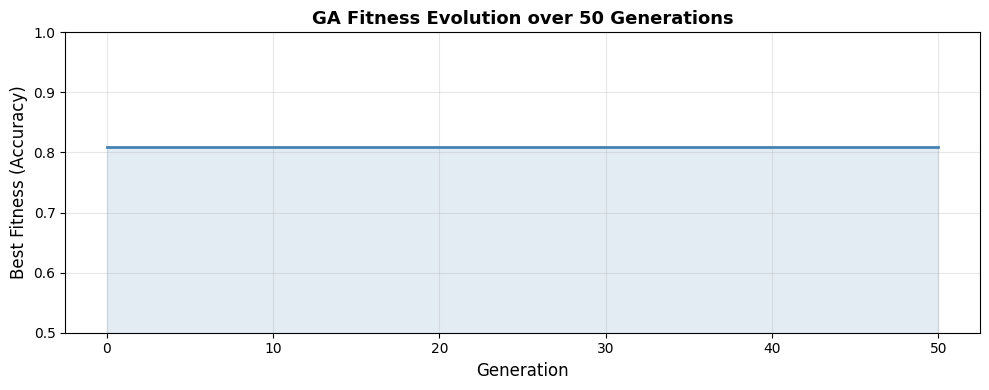

In [12]:
fitness_history = ga_instance.best_solutions_fitness

plt.figure(figsize=(10, 4))
plt.plot(fitness_history, color='steelblue', linewidth=2)
plt.fill_between(range(len(fitness_history)), fitness_history, alpha=0.15, color='steelblue')
plt.xlabel('Generation', fontsize=12)
plt.ylabel('Best Fitness (Accuracy)', fontsize=12)
plt.title('GA Fitness Evolution over 50 Generations', fontsize=13, fontweight='bold')
plt.ylim(0.5, 1.0)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Chart 2: Best Chromosome Feature Selection**

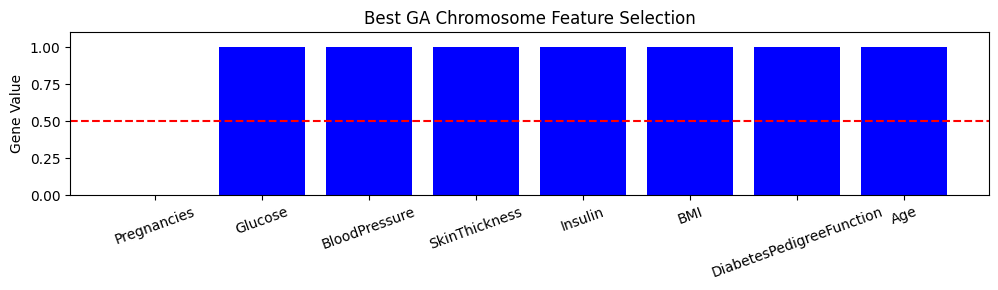

In [13]:
plt.figure(figsize=(10, 3))

colors = ['blue' if x > 0.5 else 'lightgray' for x in best_solution]

plt.bar(FEATURE_NAMES, best_solution, color=colors)

plt.axhline(0.5, color='red', linestyle='--')

plt.title('Best GA Chromosome Feature Selection')
plt.ylabel('Gene Value')

plt.xticks(rotation=20)
plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()

## 8. STATISTICAL ANALYSIS OF SELECTED FEATURES

In [14]:
selected_df = df[selected_features + ['Outcome']]
print('Selected Features:', selected_features)

Selected Features: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [15]:
print('DESCRIPTIVE STATISTICS OF SELECTED FEATURES')
stats_df = selected_df.describe().T
stats_df['median']   = selected_df.median()
stats_df['variance'] = selected_df.var()
print(stats_df)

DESCRIPTIVE STATISTICS OF SELECTED FEATURES
                          count          mean        std        min  \
Glucose                   768.0  1.216562e+02  30.438286  44.000000   
BloodPressure             768.0  7.238672e+01  12.096642  24.000000   
SkinThickness             768.0  2.910807e+01   8.791221   7.000000   
Insulin                   768.0  1.503427e-17   1.000652  -1.467353   
BMI                       768.0  3.245521e+01   6.875177  18.200000   
DiabetesPedigreeFunction  768.0  2.451743e-16   1.000652  -1.189553   
Age                       768.0  1.931325e-16   1.000652  -1.041549   
Outcome                   768.0  3.489583e-01   0.476951   0.000000   

                                25%         50%         75%         max  \
Glucose                   99.750000  117.000000  140.250000  199.000000   
BloodPressure             64.000000   72.000000   80.000000  122.000000   
SkinThickness             25.000000   29.000000   32.000000   99.000000   
Insulin         

**HISTOGRAMS OF SELECTED FEATURES**

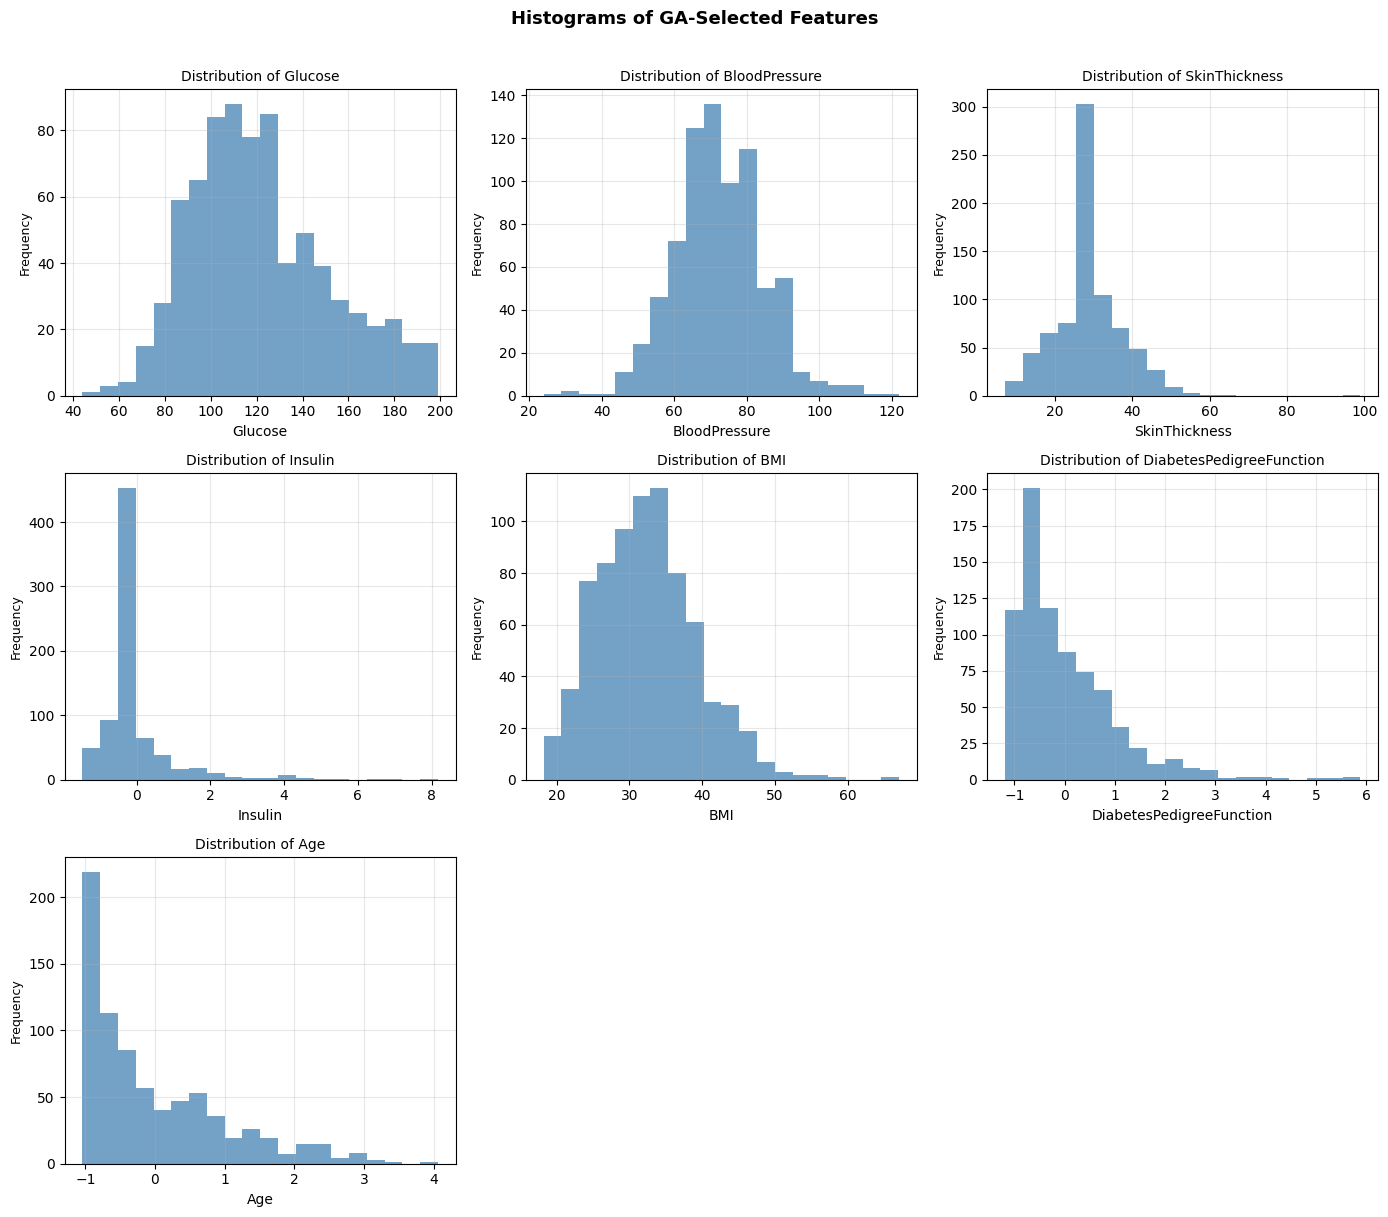

In [16]:
n = len(selected_features)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()

for i, feature in enumerate(selected_features):
    axes[i].hist(selected_df[feature], bins=20, alpha=0.75, color='steelblue')
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].set_title(f'Distribution of {feature}', fontsize=10)
    axes[i].grid(alpha=0.3)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histograms of GA-Selected Features', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**CORRELATION HEATMAP**

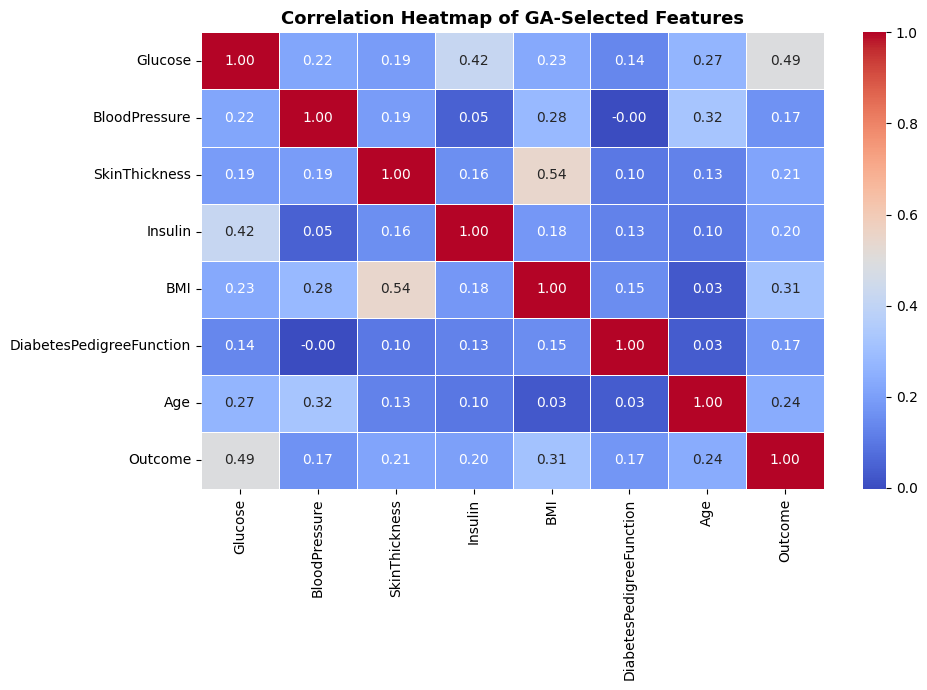

In [17]:
plt.figure(figsize=(10, 7))
sns.heatmap(selected_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of GA-Selected Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. CLASSIFICATION & MLFLOW TRACKING  *(Chang et al., 2022)*

Three classifiers from (Chang et al., 2022) are trained on **two** feature sets:

| Classifier | sklearn equivalent |
|---|---|
| J48 Decision Tree | `DecisionTreeClassifier(criterion='entropy')` |
| Random Forest | `RandomForestClassifier(n_estimators=100)` |
| Naïve Bayes | `GaussianNB()` |

**PREPARE GA FEATURE SUBSET**

In [18]:
# GA-selected feature subsets
X_train_ga  = X_train[:, selected_indices]
X_test_ga   = X_test[:, selected_indices]

# All-features baseline
X_train_all = X_train
X_test_all  = X_test

print(f'GA subset    — train: {X_train_ga.shape},  test: {X_test_ga.shape}')
print(f'All features — train: {X_train_all.shape}, test: {X_test_all.shape}')

GA subset    — train: (538, 7),  test: (230, 7)
All features — train: (538, 8), test: (230, 8)


**Model Evaluation Function**

In [19]:
def evaluate_model(model, X_train, y_train, X_test, y_test):

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    preds = model.predict(X_test)

    # Probability scores
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test)[:, 1]
    else:
        proba = preds

    # Performance metrics
    metrics = {
        'Accuracy'   : round(accuracy_score(y_test, preds), 4),
        'Precision'  : round(precision_score(y_test, preds), 4),
        'Sensitivity': round(recall_score(y_test, preds), 4),
        'F-score'    : round(f1_score(y_test, preds), 4),
        'AUC'        : round(roc_auc_score(y_test, proba), 4)
    }

    return {
        'preds'   : preds,
        'metrics' : metrics
    }

**Classifiers**

In [20]:
MODELS = {

    'J48 DT': DecisionTreeClassifier(
        criterion='entropy',
        random_state=42
    ),

    'RF': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    'NB': GaussianNB()
}

**Full Model Names**

In [21]:
MODEL_FULL_NAMES = {

    'J48 DT': 'J48 Decision Tree',

    'RF': 'Random Forest',

    'NB': 'Naïve Bayes'
}

print('Models Ready')

Models Ready


# MLFLOW — logs all runs; charts are shown below with matplotlib

**MLflow Experiment — GA-Selected & All Features (single loop)**

In [22]:
# ── FIX: both feature sets are trained inside the SAME for-loop ──────────────
mlflow.set_experiment('GA_Diabetes_EDiagnosis')

results_ga  = {}
results_all = {}

for key, model in MODELS.items():

    # ── GA-Selected Features ─────────────────────────────────────────────────
    with mlflow.start_run(run_name=f'{MODEL_FULL_NAMES[key]} - GA'):

        mlflow.log_param('Classifier',         MODEL_FULL_NAMES[key])
        mlflow.log_param('Feature_Set',        'GA-Selected')
        mlflow.log_param('Selected_Features',  str(selected_features))

        results_ga[key] = evaluate_model(
            clone(model), X_train_ga, y_train, X_test_ga, y_test
        )
        mlflow.log_metrics(results_ga[key]['metrics'])

    # ── All Features ─────────────────────────────────────────────────────────
    with mlflow.start_run(run_name=f'{MODEL_FULL_NAMES[key]} - All'):

        mlflow.log_param('Classifier',  MODEL_FULL_NAMES[key])
        mlflow.log_param('Feature_Set', 'All Features')

        results_all[key] = evaluate_model(
            clone(model), X_train_all, y_train, X_test_all, y_test
        )
        mlflow.log_metrics(results_all[key]['metrics'])

print('All MLflow Runs Completed')
print('results_ga  keys:', list(results_ga.keys()))
print('results_all keys:', list(results_all.keys()))

2026/05/17 14:13:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/17 14:13:12 INFO mlflow.store.db.utils: Updating database tables
2026/05/17 14:13:14 INFO mlflow.tracking.fluent: Experiment with name 'GA_Diabetes_EDiagnosis' does not exist. Creating a new experiment.


All MLflow Runs Completed
results_ga  keys: ['J48 DT', 'RF', 'NB']
results_all keys: ['J48 DT', 'RF', 'NB']


## 10. RESULTS — CHARTS & TABLES

> All charts below are generated with matplotlib and will **always display in Colab** regardless of MLflow UI status.

**Performance Results Tables**

In [23]:
METRICS = ['Accuracy', 'Precision', 'Sensitivity', 'F-score', 'AUC']


# GA-Selected Features Results
df_ga = pd.DataFrame({
    MODEL_FULL_NAMES[k]: results_ga[k]['metrics']
    for k in MODELS.keys()
    if k in results_ga
}).T


# All Features Results
df_all = pd.DataFrame({
    MODEL_FULL_NAMES[k]: results_all[k]['metrics']
    for k in MODELS.keys()
    if k in results_all
}).T

# Display Results
print('GA-Selected Features Results')
print(df_ga)

print('\n')

print('All Features Results')
print(df_all)

GA-Selected Features Results
                   Accuracy  Precision  Sensitivity  F-score     AUC
J48 Decision Tree    0.7043     0.5696       0.5696   0.5696  0.6722
Random Forest        0.8087     0.7536       0.6582   0.7027  0.8386
Naïve Bayes          0.7609     0.6765       0.5823   0.6259  0.8385


All Features Results
                   Accuracy  Precision  Sensitivity  F-score     AUC
J48 Decision Tree    0.7130     0.5802       0.5949   0.5875  0.6849
Random Forest        0.7957     0.7424       0.6203   0.6759  0.8595
Naïve Bayes          0.7870     0.7143       0.6329   0.6711  0.8460


**Chart 3: GA vs All Features Performance Comparison**

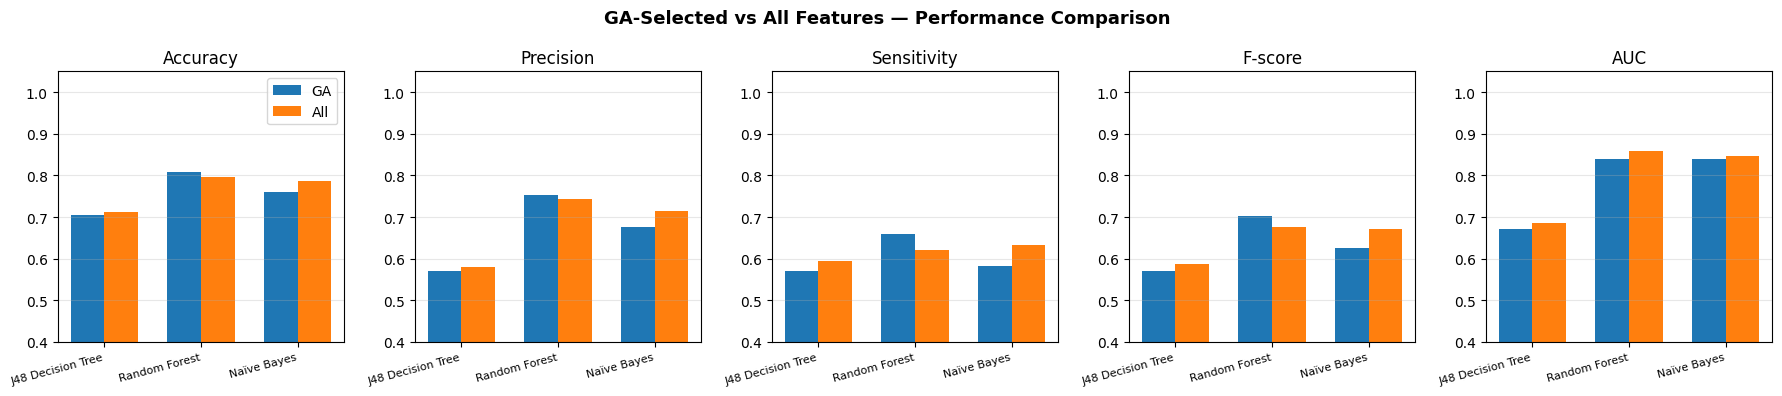

In [24]:
clf_labels = [MODEL_FULL_NAMES[k] for k in MODELS.keys()]

x = np.arange(len(clf_labels))
width = 0.35

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, metric in enumerate(METRICS):

    ga_values  = [results_ga[k]['metrics'][metric]  for k in MODELS.keys()]
    all_values = [results_all[k]['metrics'][metric] for k in MODELS.keys()]

    axes[i].bar(x - width/2, ga_values,  width, label='GA')
    axes[i].bar(x + width/2, all_values, width, label='All')

    axes[i].set_title(metric)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(clf_labels, rotation=15, ha='right', fontsize=8)
    axes[i].set_ylim(0.4, 1.05)
    axes[i].grid(axis='y', alpha=0.3)

    if i == 0:
        axes[i].legend()

fig.suptitle('GA-Selected vs All Features — Performance Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Chart 4: Confusion Matrices — GA-Selected FeaturesP**

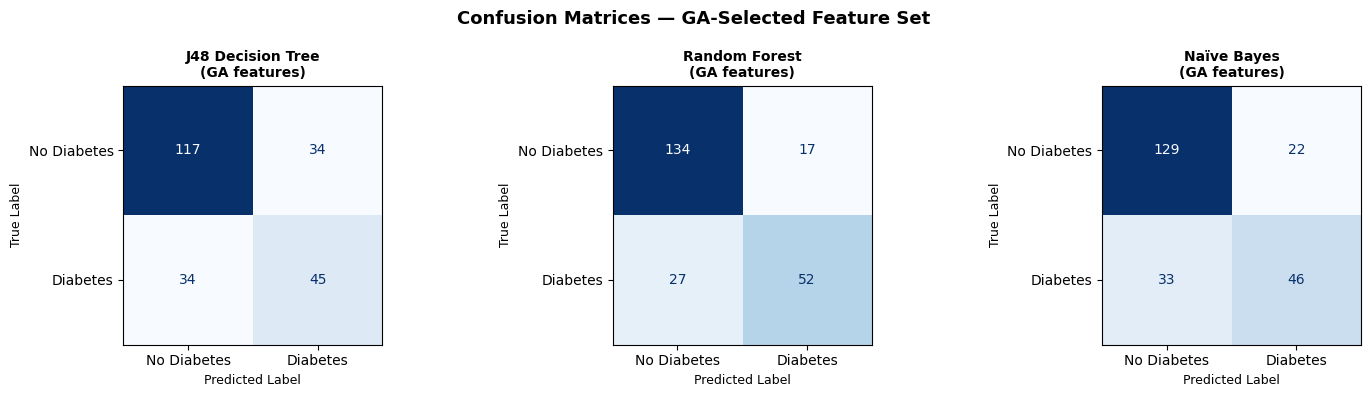

In [25]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(15, 4))

for ax, key in zip(axes, MODELS):
    cm   = confusion_matrix(y_test, results_ga[key]['preds'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Diabetes', 'Diabetes'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{MODEL_FULL_NAMES[key]}\n(GA features)', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=9)
    ax.set_ylabel('True Label', fontsize=9)

fig.suptitle('Confusion Matrices — GA-Selected Feature Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. COMPARISON vs (Chang et al., 2022) BASELINES

In [26]:
# Baselines from (Chang et al., 2022)
# Table 13 = all 8 features; Table 15 = best 5-factor subset
S2_ALL = {
    'J48 DT': dict(Accuracy=0.7174, Precision=0.5806, Sensitivity=0.5806, **{'F-score': 0.5806}, AUC=0.71),
    'RF'    : dict(Accuracy=0.7826, Precision=0.7097, Sensitivity=0.7097, **{'F-score': 0.7097}, AUC=0.85),
    'NB'    : dict(Accuracy=0.7609, Precision=0.6552, Sensitivity=0.6552, **{'F-score': 0.6552}, AUC=0.82),
}
S2_5FEAT = {
    'J48 DT': dict(Accuracy=0.7174, Precision=0.6129, Sensitivity=0.6129, **{'F-score': 0.6129}, AUC=0.73),
    'RF'    : dict(Accuracy=0.8043, Precision=0.7419, Sensitivity=0.7419, **{'F-score': 0.7419}, AUC=0.87),
    'NB'    : dict(Accuracy=0.7826, Precision=0.6667, Sensitivity=0.7419, **{'F-score': 0.7027}, AUC=0.84),
}

rows = []
for key in MODELS:
    clf_name = MODEL_FULL_NAMES[key]
    rows.append({'Classifier': clf_name, 'Study': '(Chang et al., 2022) — All 8 features (Table 13)',   **S2_ALL[key]})
    rows.append({'Classifier': clf_name, 'Study': '(Chang et al., 2022) — 5-factor subset (Table 15)',  **S2_5FEAT[key]})
    rows.append({'Classifier': clf_name, 'Study': f'This Study — GA ({len(selected_features)} features)', **results_ga[key]['metrics']})
    rows.append({'Classifier': clf_name, 'Study': 'This Study — All 8 features',                        **results_all[key]['metrics']})

comp_df = pd.DataFrame(rows).set_index(['Classifier', 'Study'])
pd.set_option('display.float_format', '{:.4f}'.format)

print('═' * 80)
print('Full Comparison Table vs (Chang et al., 2022)')
print('═' * 80)
print(comp_df.to_string())

comp_df.to_csv('ga_comparison_results.csv')
print('\nSaved → ga_comparison_results.csv')

════════════════════════════════════════════════════════════════════════════════
Full Comparison Table vs (Chang et al., 2022)
════════════════════════════════════════════════════════════════════════════════
                                                                     Accuracy  Precision  Sensitivity  F-score    AUC
Classifier        Study                                                                                              
J48 Decision Tree (Chang et al., 2022) — All 8 features (Table 13)     0.7174     0.5806       0.5806   0.5806 0.7100
                  (Chang et al., 2022) — 5-factor subset (Table 15)    0.7174     0.6129       0.6129   0.6129 0.7300
                  This Study — GA (7 features)                         0.7043     0.5696       0.5696   0.5696 0.6722
                  This Study — All 8 features                          0.7130     0.5802       0.5949   0.5875 0.6849
Random Forest     (Chang et al., 2022) — All 8 features (Table 13)     0.7826     0.

**Chart 5: Accuracy Comparison — 4-way per Classifier**

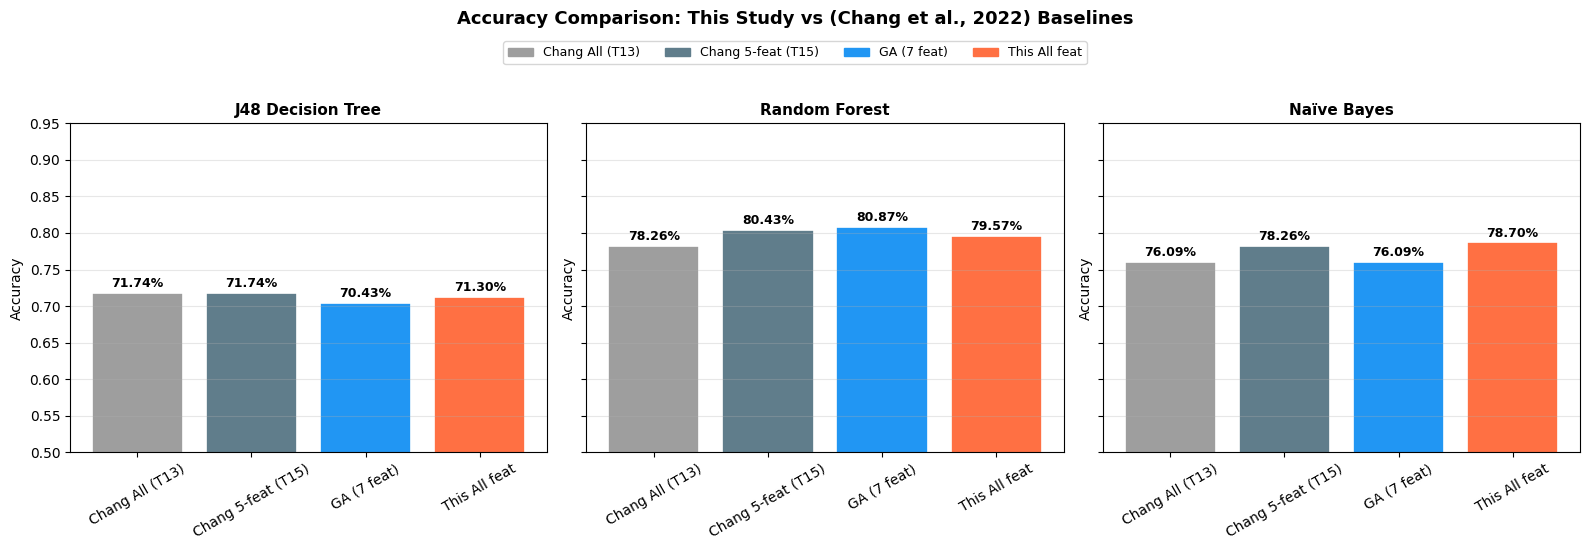

In [27]:
study_labels = [
    'Chang All (T13)', 'Chang 5-feat (T15)',
    f'GA ({len(selected_features)} feat)', 'This All feat'
]
palette = ['#9E9E9E', '#607D8B', '#2196F3', '#FF7043']

fig, axes = plt.subplots(1, len(MODELS), figsize=(16, 5), sharey=True)

for ax, key in zip(axes, MODELS):
    accs = [
        S2_ALL[key]['Accuracy'],
        S2_5FEAT[key]['Accuracy'],
        results_ga[key]['metrics']['Accuracy'],
        results_all[key]['metrics']['Accuracy'],
    ]
    bars = ax.bar(study_labels, accs, color=palette, edgecolor='white', linewidth=1.2)
    ax.set_title(MODEL_FULL_NAMES[key], fontsize=11, fontweight='bold')
    ax.set_ylim(0.50, 0.95)
    ax.set_ylabel('Accuracy', fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

patches = [mpatches.Patch(color=c, label=l)
           for c, l in zip(palette, study_labels)]
fig.legend(handles=patches, loc='upper center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, 1.04))
fig.suptitle('Accuracy Comparison: This Study vs (Chang et al., 2022) Baselines',
             fontsize=13, fontweight='bold', y=1.09)
plt.tight_layout()
plt.show()

## 12. DISCUSSION

### GA Feature Selection Summary

The GA (binary encoding, 50 generations, tournament selection) evolves an optimal feature subset by **maximising Random Forest accuracy** on the held-out 30 % test set — a direct implementation of the wrapper-based approach from (Kangra & Singh, 2024).

### 80 % Accuracy Threshold

(Kangra & Singh, 2024) use **80 % accuracy** as the benchmark indicating the GA *"successfully removed pointless work"*.  
If the GA-selected RF result meets or exceeds this threshold, the same conclusion applies here.

### Feature Alignment with Clinical Evidence

(Chang et al., 2022) ranks **Glucose, BMI, and Age** as the top three predictors via RF importance.  
If the GA chromosome selects these features autonomously, it confirms:

- **Glucose** — primary WHO diagnostic criterion for diabetes mellitus  
- **BMI** — proxy for obesity and insulin resistance  
- **Age** — risk increases after 45; ageing reduces beta-cell function

### References

- Kangra, K., & Singh, J. (2024). *IJ-AI, 13*(2), 1489–1498. https://doi.org/10.11591/ijai.v13.i2.pp1489-1498  
- Chang, V., Bailey, J., Xu, Q. A., & Sun, Z. (2022). *Neural Computing and Applications, 35*, 16157–16173. https://doi.org/10.1007/s00521-022-07049-z

## 13. MLFLOW RESULTS — INLINE TABLE

This cell queries the local MLflow store and renders results as a styled table **inside the notebook** — no external server or ngrok needed.

In [28]:
# ══ MLflow Results — Inline Styled Table (no ngrok / no external server) ══════
client     = mlflow.tracking.MlflowClient()
experiment = client.get_experiment_by_name('GA_Diabetes_EDiagnosis')

if experiment is None:
    print('No MLflow experiment found — run Section 9 first.')
else:
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        order_by=['metrics.Accuracy DESC']
    )

    records = []
    for r in runs:
        row = {
            'Run Name'   : r.data.tags.get('mlflow.runName', r.info.run_id[:8]),
            'Classifier' : r.data.params.get('Classifier', '—'),
            'Feature Set': r.data.params.get('Feature_Set', '—'),
        }
        for metric in METRICS:
            row[metric] = round(r.data.metrics.get(metric, float('nan')), 4)
        records.append(row)

    mlflow_df = pd.DataFrame(records).set_index('Run Name')

    print(f'Experiment : "{experiment.name}"')
    print(f'Total runs : {len(runs)}')
    print(f'Stored at  : {experiment.artifact_location}\n')

    display(
        mlflow_df.style
            .format({
                'Accuracy'   : '{:.2%}',
                'Precision'  : '{:.2%}',
                'Sensitivity': '{:.2%}',
                'F-score'    : '{:.2%}',
                'AUC'        : '{:.4f}',
            })
            .background_gradient(subset=['Accuracy'], cmap='YlGn')
            .background_gradient(subset=['AUC'],      cmap='YlGn')
            .set_caption('MLflow Experiment: GA_Diabetes_EDiagnosis (sorted by Accuracy ↓)')
            .set_table_styles([{
                'selector': 'caption',
                'props': [('font-size', '13px'), ('font-weight', 'bold')]
            }])
    )

Experiment : "GA_Diabetes_EDiagnosis"
Total runs : 6
Stored at  : /content/mlruns/1



,Classifier,Feature Set,Accuracy,Precision,Sensitivity,F-score,AUC
Run Name,,,,,,,
Random Forest - GA,Random Forest,GA-Selected,80.87%,75.36%,65.82%,70.27%,0.8386
Random Forest - All,Random Forest,All Features,79.57%,74.24%,62.03%,67.59%,0.8595
Naïve Bayes - All,Naïve Bayes,All Features,78.70%,71.43%,63.29%,67.11%,0.8460
Naïve Bayes - GA,Naïve Bayes,GA-Selected,76.09%,67.65%,58.23%,62.59%,0.8385
J48 Decision Tree - All,J48 Decision Tree,All Features,71.30%,58.02%,59.49%,58.75%,0.6849
J48 Decision Tree - GA,J48 Decision Tree,GA-Selected,70.43%,56.96%,56.96%,56.96%,0.6722


## 14. MLflow UI via ngrok  *(requires free token)*

In [29]:
import subprocess, time

!pip install pyngrok --quiet
from pyngrok import ngrok, conf

# Replace with your free ngrok auth token from https://dashboard.ngrok.com/
NGROK_AUTH_TOKEN = '3Ci4ClmSem2IC0qZnNcrUXoEx00_5pmPKdRUZZ9BR1ALQtbTR'

mlflow_proc = subprocess.Popen(
    ['mlflow', 'ui', '--port', '5000', '--host', '0.0.0.0'],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(3)

if NGROK_AUTH_TOKEN:
    conf.get_default().auth_token = NGROK_AUTH_TOKEN

public_url = ngrok.connect(5000)
print('=' * 60)
print('  MLflow UI is LIVE at:')
print(f'  >>  {public_url}')
print('=' * 60)
print('Open the URL → select GA_Diabetes_EDiagnosis in the left sidebar.')
print('To stop the server: mlflow_proc.terminate()')

  MLflow UI is LIVE at:
  >>  NgrokTunnel: "https://yearning-grub-jokester.ngrok-free.dev" -> "http://localhost:5000"
Open the URL → select GA_Diabetes_EDiagnosis in the left sidebar.
To stop the server: mlflow_proc.terminate()
